# Filtre de Kalman

Dans ce note book, nous allons explorer l'utilisation du filtre de Kalman.

### 2. Implementation du filtre de Kalman

Mpodel linéaire 

In [39]:
def get_disturbances(t, scenario, params):
    # Valeurs par défaut (Tableau 4.1 / Sections 4.2 & 4.3)
    p1l, p2l = params['g1']['PL'], params['g2']['PL'] # 400 et 600 MW
    kl = params['KL'] # 3064 MW/rad

    if scenario == 'EL1': # Augmentation linéaire : 100 MW en 60s
        p1l = 400 + (100 / 60) * min(t, 60)
    elif scenario == 'EL2': # Augmentation linéaire : 200 MW en 60s
        p1l = 400 + (200 / 60) * min(t, 60)
    elif scenario == 'SL1': # Échelon de charge à 15s : 500 MW
        if t >= 15: p1l = 500
    elif scenario == 'SL2': # Échelon de charge à 15s : 600 MW
        if t >= 15: p1l = 600
    elif scenario == 'PLT': # Coupure de ligne à 15s
        if t >= 15: kl = 1532 # Passage de 3064 à 1532 MW/rad

    return p1l, p2l, kl

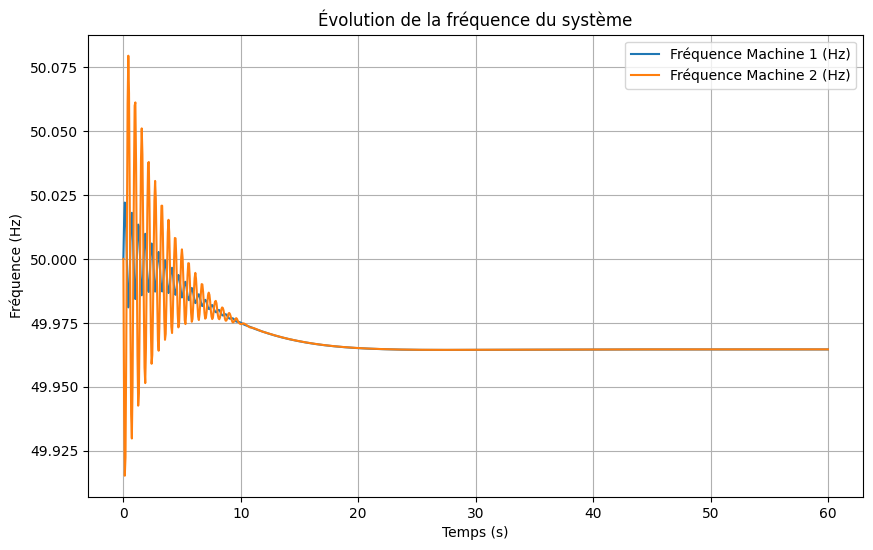

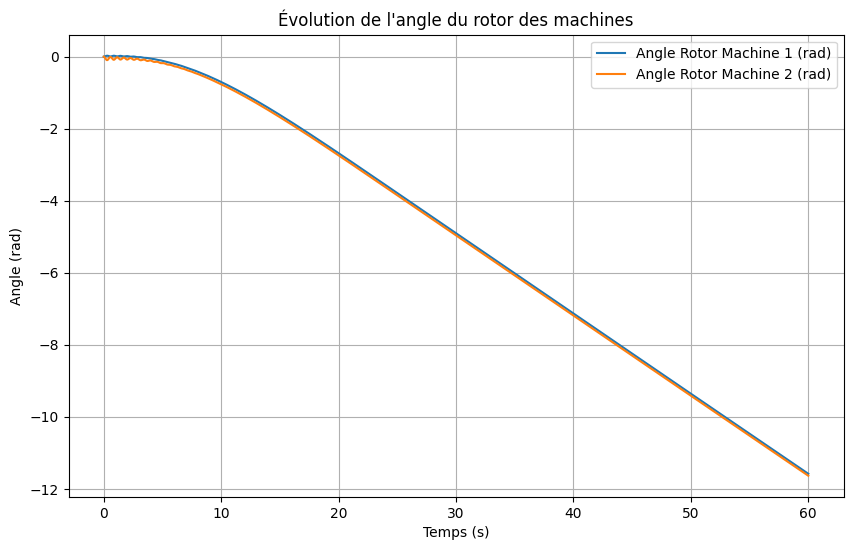

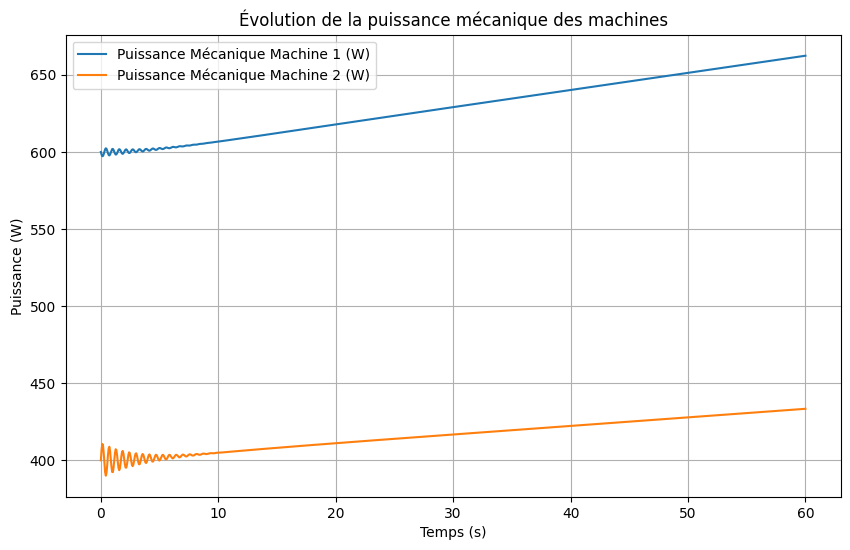

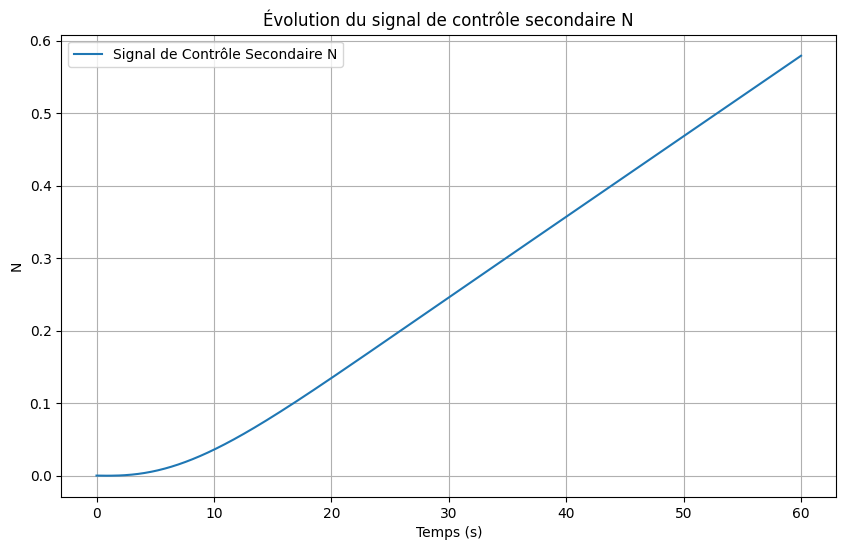

In [40]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def power_system_model(t, x, params):
    # Variables d'état
    theta1, omega1, T1m, theta2, omega2, T2m, N = x

    p1l , p2l, kl = get_disturbances(t, params['scenario'], params)
    # params['g1']['PL'] = p1l
    # params['g2']['PL'] = p2l
    # params['KL'] = kl
    
    w0 = params['omega0']
    
    # --- Équations Algébriques ---
    # Puissance échangée (Ligne)
    F12 = kl * np.sin(theta1 - theta2)
    F21 = -F12
    
    # Puissance demandée aux générateurs (Charge + Ligne)
    P1G = p1l + F12
    P2G = p2l + F21

    # Puissance mécanique actuelle
    P1m = T1m * omega1
    P2m = T2m * omega2
    
    # Consigne de puissance (Control secondaire N inclus)
    P1c = np.clip(params['g1']['P0'] + N * params['g1']['Pr'], params['g1']['Pmin'], params['g1']['Pmax'])
    P2c = np.clip(params['g2']['P0'] + N * params['g2']['Pr'], params['g2']['Pmin'], params['g2']['Pmax'])

    # --- Équations Différentielles ---
    # Générateur 1
    d_theta1 = omega1 - w0
    d_omega1 = (T1m - (P1G/omega1) - params['g1']['D']*(omega1 - w0)) / params['g1']['J']
    
    # Contrôle primaire G1 (avec condition if/else)
    if params['g1']['Pmin'] <= P1m <= params['g1']['Pmax']:
        d_T1m = -params['g1']['alpha'] * (P1m - P1c) - params['g1']['beta'] * (omega1 - w0)
    else:
        d_T1m = 0

    # Générateur 2
    d_theta2 = omega2 - w0
    d_omega2 = (T2m - (P2G/omega2) - params['g2']['D']*(omega2 - w0)) / params['g2']['J']
    
    # Contrôle primaire G2
    if params['g2']['Pmin'] <= P2m <= params['g2']['Pmax']:
        d_T2m = -params['g2']['alpha'] * (P2m - P2c) - params['g2']['beta'] * (omega2 - w0)
    else:
        d_T2m = 0

    # Contrôle Secondaire (Fréquence moyenne pondérée)
    omega_r = (params['g1']['J']*omega1 + params['g2']['J']*omega2) / (params['g1']['J'] + params['g2']['J'])
    if -1 <= N <= 1:
        dN = -params['Ks'] * (omega_r - w0)
    else:
        dN = 0

    return [d_theta1, d_omega1, d_T1m, d_theta2, d_omega2, d_T2m, dN]

# --- Initialisation des données (Tableau 4.1 et sections 4.2/4.3) ---
w0_rad = 2 * np.pi * 50

data = {
    'omega0': w0_rad,
    'KL': 3064, # Pour deux lignes selon doc
    'Ks': 0.05,
    'g1': {'P0': 600, 'Pmin': 0, 'Pmax': 1000, 'Pr': 100, 'J': 0.4, 'D': 0.04, 'alpha': 100, 'beta': 2000, 'PL': 400},
    'g2': {'P0': 400, 'Pmin': 0, 'Pmax': 600, 'Pr': 50, 'J': 0.1, 'D': 0.02, 'alpha': 100, 'beta': 2000, 'PL': 600}
}

params = {
    'f0': 50.0,
    'omega0': 2 * np.pi * 50.0,
    'KL': 3064.0,   # MW/rad (deux lignes)
    'Ks': 0.05,
    'g1': {
        'P0': 600.0, 'Pmin': 0.0, 'Pmax': 1000.0, 'Pr': 100.0,
        'J': 0.4, 'D': 0.04, 'alpha': 100.0, 'beta': 2000.0, 'PL': 400.0
    },
    'g2': {
        'P0': 400.0, 'Pmin': 0.0, 'Pmax': 600.0, 'Pr': 50.0,
        'J': 0.1, 'D': 0.02, 'alpha': 100.0, 'beta': 2000.0, 'PL': 600.0
    },
    't_event': 15.0,
    'scenario':  'EL1' # Choix : 'loadRamp1', 'loadRamp2', 'loadStep1', 'loadStep2', 'lineTrip'
}

# Conditions initiales à l'équilibre
# On estime T_initial = P_charge / omega0
x0 = [0, w0_rad, data['g1']['P0']/w0_rad, 0, w0_rad, data['g2']['P0']/w0_rad, 0]
# x0 = [0, w0_rad*1.01, 0.8, 0, w0_rad*0.99, 0.6, 0]
#-np.arcsin((data['g1']['P0'] - data['g1']['PL']) / data['KL'])
# Simulation
t_span = (0, 60)
t_eval = np.linspace(0, t_span[1], 1000)

sol = solve_ivp(power_system_model, t_span, x0, args=(params,), t_eval=t_eval, method='Radau')

theta1_sim = sol.y[0]
theta2_sim = sol.y[3]
F12_sim = data['KL'] * (theta1_sim - theta2_sim)

P1G_sim = data['g1']['PL'] + F12_sim
P2G_sim = data['g2']['PL'] + F12_sim

# --- Graphique ---
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[1]/(2*np.pi), label='Fréquence Machine 1 (Hz)')
plt.plot(sol.t, sol.y[4]/(2*np.pi), label='Fréquence Machine 2 (Hz)')
plt.title("Évolution de la fréquence du système")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='Angle Rotor Machine 1 (rad)')
plt.plot(sol.t, sol.y[3], label='Angle Rotor Machine 2 (rad)')
plt.title("Évolution de l'angle du rotor des machines")     
plt.xlabel("Temps (s)")
plt.ylabel("Angle (rad)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2]*sol.y[1], label='Puissance Mécanique Machine 1 (W)')
plt.plot(sol.t, sol.y[5]*sol.y[4], label='Puissance Mécanique Machine 2 (W)')
plt.title("Évolution de la puissance mécanique des machines")       
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[6], label='Signal de Contrôle Secondaire N')
plt.title("Évolution du signal de contrôle secondaire N")       
plt.xlabel("Temps (s)")
plt.ylabel("N")
plt.grid(True)
plt.legend()
plt.show()


In [41]:
import sympy as sp

# Define symbols
t1, w1, tm1, t2, w2, tm2, n = sp.symbols('theta1 omega1 Tm1 theta2 omega2 Tm2 N')
p10, p20, p1l, p2l, pg1, pg2, kl, w0, j1, j2, d1, d2, a1, a2, b1, b2, pr1, pr2, ks = sp.symbols(
    'P10 P20 P1L P2L PG1 PG2 KL omega0 J1 J2 D1 D2 alpha1 alpha2 beta1 beta2 Pr1 Pr2 Ks'
)

# Vector state X and equations f
X = sp.Matrix([t1, w1, tm1, t2, w2, tm2, n])

f12 = kl * (t1 - t2) # Linearized flow for the Jacobian
pg1 = p1l + f12
pg2 = p2l - f12
Y = sp.Matrix([t1, f12, pg1, pg2])  # Outputs

f = sp.Matrix([
    w1 - w0,
    (tm1 - pg1/w0 - d1*(w1 - w0))/j1,
    -a1*(tm1*w0 - (p10 + n*pr1)*w0) - b1*(w1 - w0),
    w2 - w0,
    (tm2 - pg2/w0 - d2*(w2 - w0))/j2,
    -a2*(tm2*w0 - (p20 + n*pr2)*w0) - b2*(w2 - w0),
    -ks * ((j1*w1 + j2*w2)/(j1+j2) - w0)
])

# Compute Jacobians
A_sym = f.jacobian(X)
B_sym = f.jacobian(sp.Matrix([p10, p20]))
D_sym = f.jacobian(sp.Matrix([p1l, p2l]))

C_sym = Y.jacobian(X)
E_sym = Y.jacobian(sp.Matrix([p1l, p2l]))

# Output
print("Matrix A (First row):", A_sym)
print("Matrix B(First row):", B_sym)
print("Matrix D (First row):", D_sym)
print("Matrix C (First row):", C_sym)
print("Matrix E (First row):", E_sym)


subs_dict = {
    w0:  params['omega0'],
    kl:  params['KL'], 
    ks:  params['Ks'],
    # Générateur 1
    p10: params['g1']['P0'],
    p1l: params['g1']['PL'],
    j1:  params['g1']['J'],
    d1:  params['g1']['D'],
    a1:  params['g1']['alpha'],
    b1:  params['g1']['beta'],
    pr1: params['g1']['Pr'],
    # Générateur 2
    p20: params['g2']['P0'],
    p2l: params['g2']['PL'],
    j2:  params['g2']['J'],
    d2:  params['g2']['D'],
    a2:  params['g2']['alpha'],
    b2:  params['g2']['beta'],
    pr2: params['g2']['Pr']
}

# On remplace les symboles et on convertit en flottants (np.float64)
A_num = np.array(A_sym.subs(subs_dict)).astype(np.float64)
B_num = np.array(B_sym.subs(subs_dict)).astype(np.float64)
C_num = np.array(C_sym.subs(subs_dict)).astype(np.float64)
D_num = np.array(D_sym.subs(subs_dict)).astype(np.float64)
E_num = np.array(E_sym.subs(subs_dict)).astype(np.float64)

print("Numeric A Matrix:\n", A_num)

# 1. Récupérer la dimension du système (n)
n = A_num.shape[0]

# 2. Construction de la matrice d'observabilité
# On empile verticalement C, CA, CA^2, ..., CA^(n-1)
obs_blocks = [C_num @ np.linalg.matrix_power(A_num, i) for i in range(n)]
Obs_matrix = np.vstack(obs_blocks)
print("Observability Matrix:\n", Obs_matrix)
# 3. Calcul du rang de la matrice
rank_obs = np.linalg.matrix_rank(Obs_matrix, tol=1e-8)

# Affichage des résultats
print(f"Matrice d'observabilité (shape) : {Obs_matrix.shape}")
print(f"Rang de la matrice d'observation : {rank_obs}")
print(f"Dimension de l'état (n) : {n}")

if rank_obs == n:
    print("✅ Le système est observable (rang plein).")
else:
    print(f"❌ Le système n'est PAS observable ({n - rank_obs} modes inobservables).")

Matrix A (First row): Matrix([[0, 1, 0, 0, 0, 0, 0], [-KL/(J1*omega0), -D1/J1, 1/J1, KL/(J1*omega0), 0, 0, 0], [0, -beta1, -alpha1*omega0, 0, 0, 0, Pr1*alpha1*omega0], [0, 0, 0, 0, 1, 0, 0], [KL/(J2*omega0), 0, 0, -KL/(J2*omega0), -D2/J2, 1/J2, 0], [0, 0, 0, 0, -beta2, -alpha2*omega0, Pr2*alpha2*omega0], [0, -J1*Ks/(J1 + J2), 0, 0, -J2*Ks/(J1 + J2), 0, 0]])
Matrix B(First row): Matrix([[0, 0], [0, 0], [alpha1*omega0, 0], [0, 0], [0, 0], [0, alpha2*omega0], [0, 0]])
Matrix D (First row): Matrix([[0, 0], [-1/(J1*omega0), 0], [0, 0], [0, 0], [0, -1/(J2*omega0)], [0, 0], [0, 0]])
Matrix C (First row): Matrix([[1, 0, 0, 0, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0], [-KL, 0, 0, KL, 0, 0, 0]])
Matrix E (First row): Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
Numeric A Matrix:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.43825373e+01 -1.00000000e-01  2.50000000e+00  2.43825373e+01
   0.00000000e+00  0

Senario : EL1


100%|██████████| 999999/999999 [00:07<00:00, 133350.19it/s]


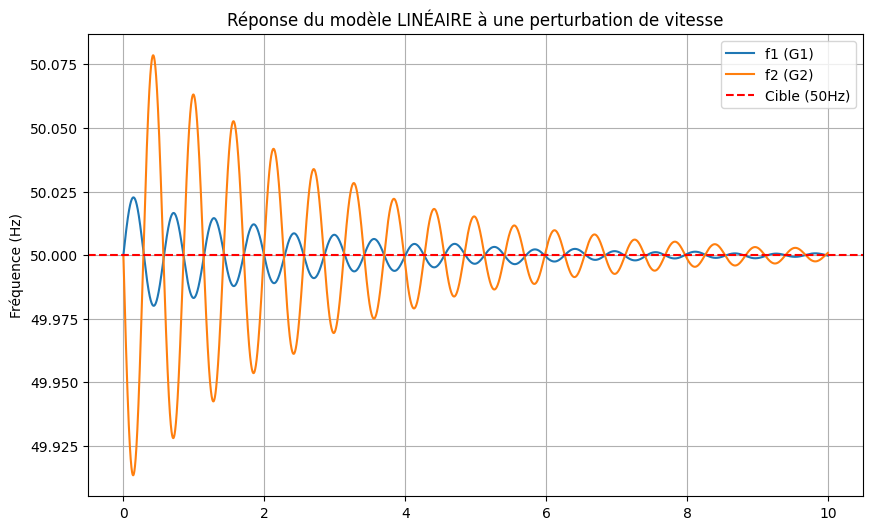

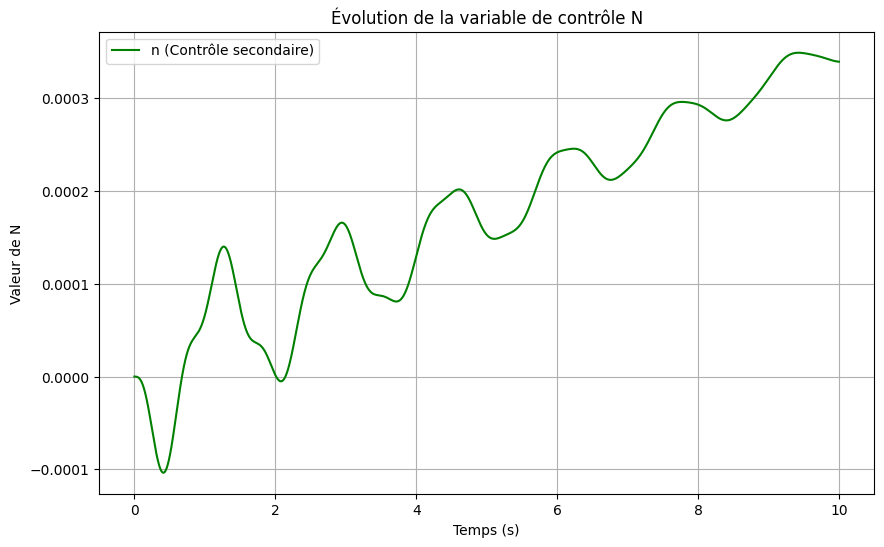

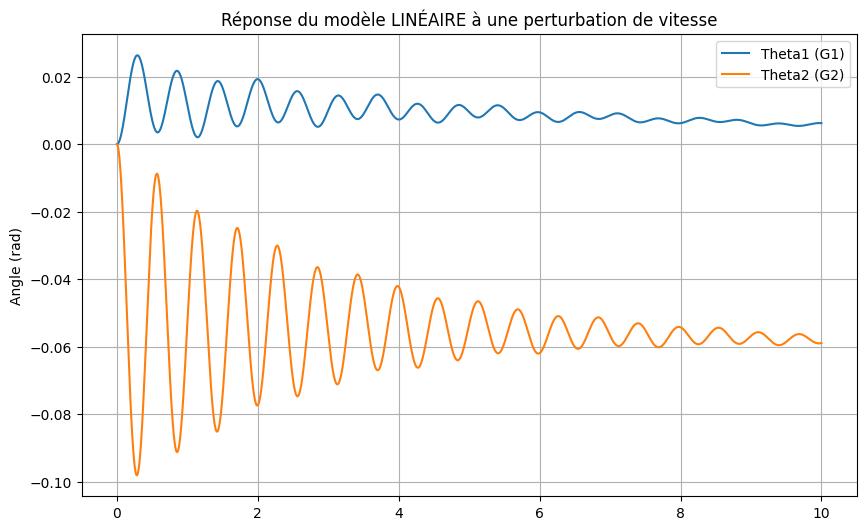

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm

# --- 1. Définition du point d'équilibre (Equilibrium) ---
# On utilise x0 comme point d'équilibre (xeq)

x0 = np.array([0, params['omega0'], data['g1']['P0']/params['omega0'], 0, params['omega0'], data['g2']['P0']/params['omega0'], 0])
# x0 = np.array([0, params['omega0']*1.01, 0.8, 0, params['omega0']*0.99, 0.6, 0])
#-np.arcsin((data['g1']['P0'] - data['g1']['PL']) / data['KL'])
# x_eq = np.array(x0).copy()
# x_eq[3] = -np.arcsin((params['g1']['P0'] - params['g1']['PL0']) / params['KL_nom'])
x_eq = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), params['omega0'], params['g2']['P0']/params['omega0'], 0])
u_eq = np.array([params['g1']['P0'], params['g2']['P0']])
w_eq = np.array([params['g1']['PL'], params['g2']['PL']])

# --- 2. Configuration de la simulation ---
dt = 0.00001  # Avec le modèle linéaire, 0.001s est généralement suffisant
t_final = 10.0
t_steps = np.arange(0, t_final, dt)

# --- 3. Initialisation des écarts (Delta X) ---
# Si on commence pile à l'équilibre, delta_x = 0
# Ajoutons une petite perturbation initiale sur la vitesse de G1 pour voir la dynamique
delta_x0 = x0 - x_eq
# delta_x0[1] = 0.1  # Perturbation de +0.1 rad/s sur omega1

x_history = np.zeros((len(t_steps), len(delta_x0)))
x_history[0] = x0

print("Senario :", params['scenario'])


# --- 4. Entrées (écarts par rapport au point de linéarisation) ---
# Si on ne change pas les consignes, delta_u et delta_w sont nuls
delta_u = np.array([0.0, 0.0]) 
delta_w = np.array([0.0, 0.0]) 

# --- 5. Boucle d'Euler ---
delta_x_current = delta_x0.copy()

for i in tqdm.tqdm(range(1, len(t_steps))):
    
    p1l, p2l, kl = get_disturbances(t_steps[i], params['scenario'], params)
    delta_w = np.array([p1l, p2l]) - w_eq  
    
    
    # Dynamique des écarts : d(delta_x)/dt = A*delta_x + B*delta_u + D*delta_w
    d_delta_x_dt = A_num @ delta_x_current + B_num @ delta_u + D_num @ delta_w
    
    # Mise à jour
    delta_x_current = delta_x_current + d_delta_x_dt * dt
    x_history[i] = delta_x_current + x_eq

# --- 6. Reconstruction des variables absolues pour l'affichage ---
# x_absolu = x_eq + delta_x
x_final_history = x_history.copy()

x_final_history[:, 1] = x_final_history[:, 1]/(2*np.pi)  # omega1
x_final_history[:, 4] = x_final_history[:, 4] / (2*np.pi)  # omega2

y_final_history = np.zeros((len(t_steps), 4))
for i in range(len(t_steps)):
    theta1_i = x_final_history[i, 0]
    theta2_i = x_final_history[i, 3]
    f12_i = params['KL'] * (theta1_i - theta2_i)
    p1l_i = params['g1']['PL']
    p2l_i = params['g2']['PL']
    y_final_history[i, 0] = theta1_i
    y_final_history[i, 1] = f12_i
    y_final_history[i, 2] = p1l_i + f12_i
    y_final_history[i, 3] = p2l_i - f12_i


# --- 7. Visualisation ---
plt.figure(figsize=(10, 6))

plt.plot(t_steps, x_final_history[:, 1], label='f1 (G1)')
plt.plot(t_steps, x_final_history[:, 4], label='f2 (G2)')
plt.axhline(y=params['omega0'] / (2*np.pi), color='r', linestyle='--', label='Cible (50Hz)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_steps, x_final_history[:, 6], label='n (Contrôle secondaire)', color='green')
plt.title("Évolution de la variable de contrôle N")
plt.xlabel("Temps (s)")
plt.ylabel("Valeur de N")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_steps, x_final_history[:, 0], label='Theta1 (G1)')
plt.plot(t_steps, x_final_history[:, 3], label='Theta2 (G2)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
from tqdm import tqdm
# --- 1. Discrétisation ---
Ad = np.eye(7) + A_num * dt
Bd = B_num * dt
Dd = D_num * dt
C_obs = C_num  # Jacobienne de Y par rapport à X (3x7)
E_obs = E_num # Impact direct de P1L et P2L sur Pg1/Pg2

# --- 2. Paramètres du filtre (Incertitudes) ---
Q = np.eye(7) * 1e-3  # Bruit de processus (Confiance modèle)
R = np.eye(4) * 1e-3  # Bruit de mesure (Confiance capteurs)

# --- 3. Initialisation ---
delta_x_hat = delta_x0.copy().reshape(-1, 1) # Estimation initiale de l'écart
y_eq = C_obs @ x_eq.reshape(-1, 1) + E_obs @ w_eq.reshape(-1, 1)
P_cov = np.eye(7) * 0.1                      # Incertitude initiale
delta_x_hat_history = np.zeros((len(t_steps), 7))
y_hat_history = np.zeros((len(t_steps), 4))

# Préparation des vecteurs colonnes pour les entrées (fixes dans ce scénario)
du = delta_u.reshape(-1, 1)
dw = delta_w.reshape(-1, 1)

x_reel = x_final_history.reshape(-1, 1)
# --- Configuration du bruit via SNR pour 3 canaux ---
snr_db = 40 
signal_power_per_channel = np.mean(y_final_history**2, axis=0)
snr_linear = 10**(snr_db / 10)
noise_power_per_channel = signal_power_per_channel / snr_linear
sigma_noise_per_channel = np.sqrt(noise_power_per_channel)
noise = np.random.normal(0, 1, y_final_history.shape) * sigma_noise_per_channel
y_reel = y_final_history + noise

sigma_noise_pl = np.sqrt([params['g1']['PL']**2 / snr_linear, params['g2']['PL']**2 / snr_linear]) 
print("Sigma Noise P1L, P2L :", sigma_noise_pl)
print("Sigma Noise Y channels :", sigma_noise_per_channel)


# R = np.diag(noise_power_per_channel)

for i in tqdm(range(len(t_steps))):
    # --- 1. ACQUISITION ET CALCUL DES ÉCARTS DE MESURE ---
    
    p1l, p2l, kl = get_disturbances(t_steps[i], params['scenario'], params)
    # delta_w = np.array([p1l+np.random.normal(0, sigma_noise_pl[0]), p2l + np.random.normal(0, sigma_noise_pl[1])]) - w_eq  
    delta_w = np.array([p1l, p2l]) - w_eq
    delta_w = np.array([100/60*t_steps[i],0.0])
    dw = delta_w.reshape(-1, 1)
    # Calcul de l'équilibre de mesure y_eq (pour obtenir l'écart delta_y)
    
    delta_y = y_reel[i].reshape(-1, 1) - y_eq

    # --- 2. ÉTAPE DE PRÉDICTION (A Priori) ---
    delta_x_hat_minus = Ad @ delta_x_hat + Bd @ du + Dd @ dw
    P_minus = Ad @ P_cov @ Ad.T + Q

    # --- 3. ÉTAPE DE CORRECTION (A Posteriori) ---
    # Innovation basée sur les écarts
    innovation = delta_y - (C_obs @ delta_x_hat_minus + E_obs @ dw)
    
    S = C_obs @ P_minus @ C_obs.T + R
    K = P_minus @ C_obs.T @ np.linalg.inv(S)
    
    delta_x_hat = delta_x_hat_minus + K @ innovation
    P_cov = (np.eye(7) - K @ C_obs) @ P_minus
    
    # Stockage de l'estimation de l'écart
    delta_x_hat_history[i] = delta_x_hat.flatten()
    
    # --- 4. RECONSTRUCTION DE LA SORTIE ESTIMÉE ---
    delta_y_hat = C_obs @ delta_x_hat + E_obs @ dw
    
    # Reconstruction de la sortie totale estimée (Valeur filtrée)
    y_hat_total = delta_y_hat + y_eq
    
    # Stockage
    y_hat_history[i] = y_hat_total.flatten()

Sigma Noise P1L, P2L : [4. 6.]
Sigma Noise Y channels : [1.02817563e-04 2.04141370e+00 5.99575770e+00 4.06137406e+00]


100%|██████████| 1000000/1000000 [01:40<00:00, 9914.42it/s]


--- SNR de l'estimation des sorties (Post-Kalman) ---
SNR Theta1 : 32.51 dB
SNR F12 : 34.00 dB
SNR Pg1 : 38.80 dB
SNR Pg2 : 39.98 dB

--- Amélioration apportée par le filtre ---
Gain SNR Theta1 : +-7.50 dB
Gain SNR F12 : +-5.99 dB
Gain SNR Pg1 : +-1.21 dB
Gain SNR Pg2 : +-0.02 dB


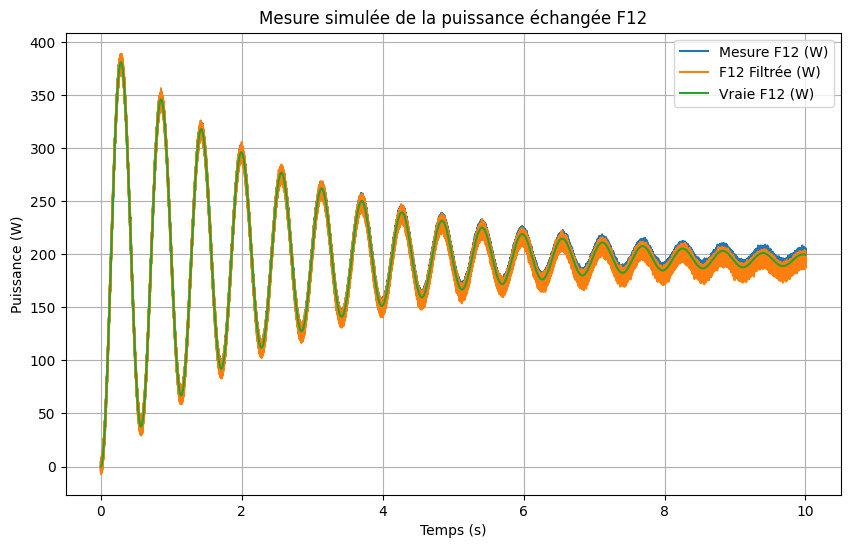

In [44]:
# --- Calcul du SNR pour les sorties y_hat ---
erreur_y = y_final_history - y_hat_history
puissance_signal_y = np.mean(y_final_history**2, axis=0)
puissance_bruit_y = np.mean(erreur_y**2, axis=0)
snr_y_db = 10 * np.log10(puissance_signal_y / puissance_bruit_y)
canaux = ['Theta1', 'F12', 'Pg1', 'Pg2']
print("--- SNR de l'estimation des sorties (Post-Kalman) ---")
for i, nom in enumerate(canaux):
    print(f"SNR {nom} : {snr_y_db[i]:.2f} dB")
puissance_bruit_initial = np.mean((y_reel - y_final_history)**2, axis=0)
snr_initial_db = 10 * np.log10(puissance_signal_y / puissance_bruit_initial)
gain_db = snr_y_db - snr_initial_db

print("\n--- Amélioration apportée par le filtre ---")
for i, nom in enumerate(canaux):
    print(f"Gain SNR {nom} : +{gain_db[i]:.2f} dB")

plt.figure(figsize=(10, 6))
plt.plot(t_steps, y_reel[:,1], label='Mesure F12 (W)')
plt.plot(t_steps, y_hat_history[:,1], label='F12 Filtrée (W)')
plt.plot(t_steps, y_final_history[:,1], label='Vraie F12 (W)')
plt.title("Mesure simulée de la puissance échangée F12")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)") 
plt.grid(True)
plt.legend()
plt.show()

SNR de l'estimation (G1) : 76.24 dB


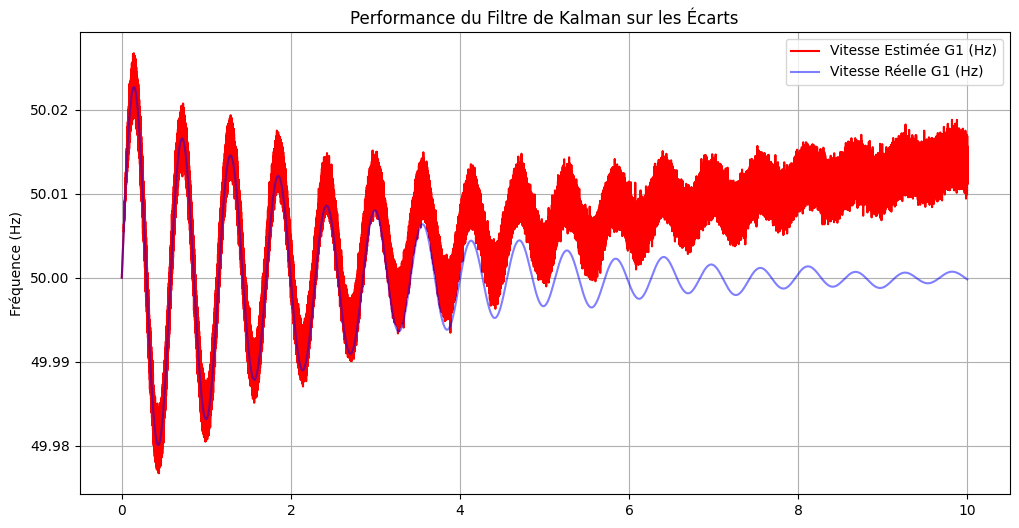

In [45]:

# Valeurs absolues estimées
x_hat_final = delta_x_hat_history + x_eq

# Calcul du SNR de l'estimation pour la vitesse de G1
signal_reel = x_final_history[:, 1] 
signal_estime = (delta_x_hat_history[:, 1] + x_eq[1]) / (2 * np.pi)
erreur = signal_reel - signal_estime
puissance_signal = np.mean(signal_reel**2)
puissance_bruit = np.mean(erreur**2)
snr_estime_db = 10 * np.log10(puissance_signal / puissance_bruit)

print(f"SNR de l'estimation (G1) : {snr_estime_db:.2f} dB")

plt.figure(figsize=(12, 6))
plt.plot(t_steps, x_hat_final[:, 1] / (2*np.pi), 'r', label='Vitesse Estimée G1 (Hz)')
plt.plot(t_steps, x_final_history[:, 1], 'b', alpha=0.5, label='Vitesse Réelle G1 (Hz)')
plt.title("Performance du Filtre de Kalman sur les Écarts")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)
plt.show()